In [1]:
# Downloading data
# wiki_ai.txt
#wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1C8NhBH1ZFgZCbWJ7bW3DsFfWhuD9fXuW' -O snlp_cw1_pragnya.txt

import wget
# snlp_cw1_pragnya.txt (for Part 1)
url = "https://docs.google.com/uc?export=download&id=1C8NhBH1ZFgZCbWJ7bW3DsFfWhuD9fXuW"
filename = wget.download(url)
# Training data (for Part 2)
#url = "https://docs.google.com/uc?export=download&id=1C8NhBH1ZFgZCbWJ7bW3DsFfWhuD9fXuW"
#filename = wget.download(url)

# Test data (for Part 2)
#url = "https://docs.google.com/uc?export=download&id=1C8NhBH1ZFgZCbWJ7bW3DsFfWhuD9fXuW"
#filename = wget.download(url)

# Full dataset (for Part 3)
# tokenized, sentence, lower casing and some normlization
#url = "https://docs.google.com/uc?export=download&id=1C8NhBH1ZFgZCbWJ7bW3DsFfWhuD9fXuW"
#filename = wget.download(url)

# Original dataset (fyi, not used in this Practical Session)
#url = "https://docs.google.com/uc?export=download&id=1C8NhBH1ZFgZCbWJ7bW3DsFfWhuD9fXuW"
#filename = wget.download(url)

100% [................................................................................] 2092 / 2092

In [3]:
with open('snlp_cw1_pragnya.txt') as infile:
    text = infile.read()

print(text)

Hello! My name is Pragnya Sri Arsha, and I am passionate about Artificial Intelligence, Data science, and Data Analyst. My primary aim is to contribute impactful research and develop the AI-driven solutions that solve our day-to-day real-world problems. I hold a Bachelor's degree from SR University and I'm pursuing my Master's degree at Edinburgh Napier University in Scotland, United Kingdom, where I specialized in Advanced computing and Data-driven technologies. My studies provided me with a solid foundation in Machine Learning, Data Analysis, Programming in (Python, C, C++, Java), and Database Management Systems. I have gained practical experience through Internships and Academic projects in Full-Stack Development, Machine Learning and AI based applications, which strengthened my technical problem-solving skills and teamwork abilities. This experience has enhanced my skills in data preprocessing, model development, web application development (Django), and cloud-based AI tools. I hav

In [4]:
import spacy

nlp = spacy.load('en_core_web_sm')
print('spaCy is doing the work')
# Read in a string of characters
with open('snlp_cw1_pragnya.txt') as inFile:
    text = inFile.read()

# Preprocess using spacy's pipeline
doc = nlp(text)

print('Preprocessing done.')

spaCy is doing the work
Preprocessing done.


### 1.Tokenise the input text into words and answer the following question

In [5]:
#1) tokenized into words(ignore punctuation and spaces)
words = [t.text.lower() for t in doc if t.is_alpha]
print("Sample tokens:", words)

Sample tokens: ['hello', 'my', 'name', 'is', 'pragnya', 'sri', 'arsha', 'and', 'i', 'am', 'passionate', 'about', 'artificial', 'intelligence', 'data', 'science', 'and', 'data', 'analyst', 'my', 'primary', 'aim', 'is', 'to', 'contribute', 'impactful', 'research', 'and', 'develop', 'the', 'ai', 'driven', 'solutions', 'that', 'solve', 'our', 'day', 'to', 'day', 'real', 'world', 'problems', 'i', 'hold', 'a', 'bachelor', 'degree', 'from', 'sr', 'university', 'and', 'i', 'pursuing', 'my', 'master', 'degree', 'at', 'edinburgh', 'napier', 'university', 'in', 'scotland', 'united', 'kingdom', 'where', 'i', 'specialized', 'in', 'advanced', 'computing', 'and', 'data', 'driven', 'technologies', 'my', 'studies', 'provided', 'me', 'with', 'a', 'solid', 'foundation', 'in', 'machine', 'learning', 'data', 'analysis', 'programming', 'in', 'python', 'c', 'java', 'and', 'database', 'management', 'systems', 'i', 'have', 'gained', 'practical', 'experience', 'through', 'internships', 'and', 'academic', 'proje

### (i)Find the total no.of words

In [6]:
#total no of words
total_words = len(words)
print("Total no.of words=", total_words)

Total no.of words= 302


### (ii) Find the total number of distinct (or unique) words

In [7]:
#total number of distinct (or unique) words
unq_words = len(set(words))
print("Total no.of unique words=", unq_words)

Total no.of unique words= 176


### (iii) Find the average length of the words

In [8]:
#Average length of the words
avglen_words = sum(len(w) for w in words) / total_words if total_words else 0

print("Average length of words=", round(avglen_words, 2))

Average length of words= 5.66


### (iv)Visualise a frequency distribution of the words occurring

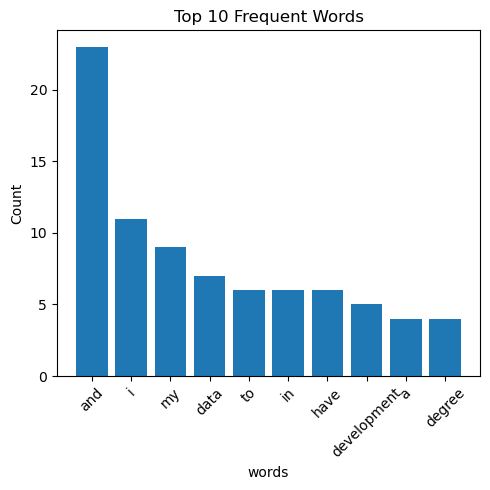

In [9]:
# Visualising a frequency distribution of the words occurring
from collections import Counter
import matplotlib.pyplot as plt

# Count word frequency
word_freq = Counter(words)

# Get top 10 most common words
common_words = word_freq.most_common(10)

# Separate words and counts
word_list = [item[0] for item in common_words]
counts = [item[1] for item in common_words]

# Plot
plt.figure(figsize=(5, 5))
plt.bar(word_list, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Frequent Words")
plt.xlabel("words")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### (v) Visualise a frequency distribution of the Parts-of-speech (POS) tags of the words

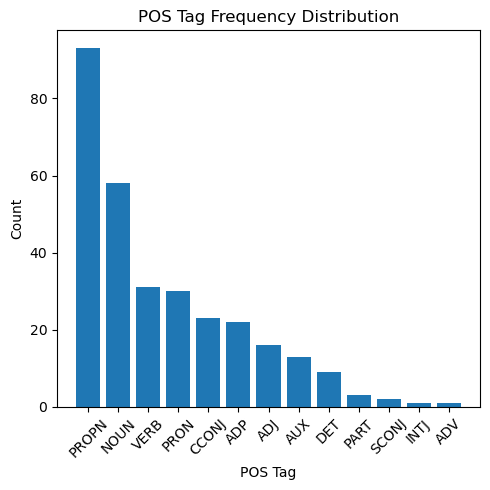

In [10]:
# Visualising a frequency distribution of the Parts-of-speech (POS) tags of the words
# Extract POS tags
pos_tags = [token.pos_ for token in doc if token.is_alpha]

# Count POS frequency
pos_freq = Counter(pos_tags)

# Get most common POS tags
common_pos = pos_freq.most_common()

pos_list = [item[0] for item in common_pos]
pos_counts = [item[1] for item in common_pos]

# Plot
plt.figure(figsize=(5, 5))
plt.bar(pos_list, pos_counts)
plt.xticks(rotation=45)
plt.title("POS Tag Frequency Distribution")
plt.xlabel("POS Tag")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 2. Segment the input text into sentences

In [11]:
# Segment the input text into sentences:
# Extract sentences from spaCy document
sentence = [sent.text.strip() for sent in doc.sents]
print("Sample sentences:")
for s in sentence[:3]:
    print(s)

Sample sentences:
Hello!
My name is Pragnya Sri Arsha, and I am passionate about Artificial Intelligence, Data science, and Data Analyst.
My primary aim is to contribute impactful research and develop the AI-driven solutions that solve our day-to-day real-world problems.


### (i)Find the total number of sentences and the average length of the sentences.

In [12]:
# Total number of sentences and the average length of the sentences.
total_sentence = len(sentence)
print("Total number of sentences:", total_sentence)

# Calculate sentence lengths (word count per sentence)
sentence_lengths = []
for sent in doc.sents:
    words_in_sentence = [token.text for token in sent if token.is_alpha]
    sentence_lengths.append(len(words_in_sentence))

# Average sentence length
average_sentence_length = sum(sentence_lengths) / total_sentence if total_sentence else 0
print("Average sentence length in words:", round(average_sentence_length, 2))


Total number of sentences: 16
Average sentence length in words: 18.88


### (iii)Sort the sentences in descending order of their lengths.

In [13]:
# Sort the sentences in descending order of their lengths.
sentence_with_length=[]
for sent in doc. sents:
    word_in_sentence=[token.text for token in sent if token.is_alpha]
    sentence_with_length.append((sent.text.strip(),len(word_in_sentence)))
    
# sort by length(descending)
sort_sentence=sorted(sentence_with_length,
                    key=lambda x: x[1],
                    reverse=True)
print("\nSorted 15 sentence by length in descending:\n")

for sentence, length in sort_sentence[:5]:
    print(f"Length: {length} words")
    print(sentence)
    print("-" * 50)


Sorted 15 sentence by length in descending:

Length: 42 words
I have been fortunate to receive several scholarships, including Edinburgh Napier University for Master's degree and Ts EPASS Scholarship for Bachelor's degree, and Certifications including AWS Academy Cloud Foundations, IBM Data Structures and Algorithms, and Cybersecurity Essentials, which have supported my education.
--------------------------------------------------
Length: 39 words
I have developed a diverse skill set that includes Programming (Python, Java, C, C++), Data Analysis and Machine Learning, Web Development (Django Framework includes Html, CSS, JavaScript), Database Management (Oracle, SQL), Business Intelligence and Reporting, Problem Solving and Analytical Thinking.
--------------------------------------------------
Length: 32 words
I hold a Bachelor's degree from SR University and I'm pursuing my Master's degree at Edinburgh Napier University in Scotland, United Kingdom, where I specialized in Advanced co

### 3) Carry out the Named Entity Recognition (NER) in the input text
### (i) Print out each named entity, together with the label assigned to it


In [14]:
# Carry out the Named Entity Recognition (NER) in the input text
# Print out each named entity, together with the label assigned to it
# Extract and print named entities
print("Name of Entities and their Labels:\n")

for entity in doc.ents:
    print(f"Entity: {entity.text}  |  Label: {entity.label_}")

Name of Entities and their Labels:

Entity: Pragnya Sri Arsha  |  Label: FAC
Entity: Artificial Intelligence  |  Label: ORG
Entity: Data  |  Label: ORG
Entity: AI  |  Label: GPE
Entity: Bachelor  |  Label: ORG
Entity: SR University  |  Label: ORG
Entity: Edinburgh Napier University  |  Label: ORG
Entity: Scotland  |  Label: GPE
Entity: United Kingdom  |  Label: GPE
Entity: Machine Learning, Data Analysis  |  Label: ORG
Entity: C++  |  Label: PERSON
Entity: Java  |  Label: PERSON
Entity: Database Management Systems  |  Label: ORG
Entity: Internships  |  Label: ORG
Entity: Full-Stack Development  |  Label: ORG
Entity: Machine Learning  |  Label: PERSON
Entity: AI  |  Label: GPE
Entity: Django  |  Label: PERSON
Entity: AI  |  Label: GPE
Entity: Programming (Python  |  Label: ORG
Entity: Java  |  Label: PERSON
Entity: C++  |  Label: PERSON
Entity: Data Analysis and Machine Learning  |  Label: ORG
Entity: Html  |  Label: PERSON
Entity: CSS  |  Label: ORG
Entity: JavaScript  |  Label: ORG
En

### (ii)Visualise the named entities directly in the text and explain different named entity labels

In [15]:
# Visualising the named entities directly in the text and explain different named entity labels
from spacy import displacy

# Visualise entities
displacy.render(doc, style="ent", jupyter=True)

### 4) Perform a syntactic parsing of the first three sentences of the input text

In [16]:
# Performing a syntactic parsing of the first three sentences of the input text

sentences = list(doc. sents)
first_three = sentences[:3]
for i, sent in enumerate(first_three, start=1):
    print(f"Sentence {i}: {sent.text}\n")


Sentence 1: Hello!

Sentence 2: My name is Pragnya Sri Arsha, and I am passionate about Artificial Intelligence, Data science, and Data Analyst.

Sentence 3: My primary aim is to contribute impactful research and develop the AI-driven solutions that solve our day-to-day real-world problems.



### (i)Visualise a dependency graph over the first three sentences

In [17]:
# Visualising a dependency graph over the first three sentences
from spacy import displacy
for i, s in enumerate(first_three, start=1):
    print(f"\nDependency graph for sentence {i}:")
    displacy.render(nlp(s.text), style="dep", jupyter=True)


Dependency graph for sentence 1:



Dependency graph for sentence 2:



Dependency graph for sentence 3:


### (ii)Navigate the parse tree and print the attributes associated with each element of the tree. 

In [18]:
# Navigate the parse tree and print the attributes associated with each element of the tree. 
for i, sent in enumerate(first_three, 1):
    print(f"\n--- Sentence {i} ---\n")
    
    for token in sent:
        print(f"""
        TEXT: {token.text}
        LEMMA: {token.lemma_}
        POS: {token.pos_}
        TAG: {token.tag_}
        DEP: {token.dep_}
        HEAD: {token.head.text}
        IS_STOP: {token.is_stop}
        """)


--- Sentence 1 ---


        TEXT: Hello
        LEMMA: hello
        POS: INTJ
        TAG: UH
        DEP: ROOT
        HEAD: Hello
        IS_STOP: False
        

        TEXT: !
        LEMMA: !
        POS: PUNCT
        TAG: .
        DEP: punct
        HEAD: Hello
        IS_STOP: False
        

--- Sentence 2 ---


        TEXT: My
        LEMMA: my
        POS: PRON
        TAG: PRP$
        DEP: poss
        HEAD: name
        IS_STOP: True
        

        TEXT: name
        LEMMA: name
        POS: NOUN
        TAG: NN
        DEP: nsubj
        HEAD: is
        IS_STOP: True
        

        TEXT: is
        LEMMA: be
        POS: AUX
        TAG: VBZ
        DEP: ROOT
        HEAD: is
        IS_STOP: True
        

        TEXT: Pragnya
        LEMMA: Pragnya
        POS: PROPN
        TAG: NNP
        DEP: compound
        HEAD: Arsha
        IS_STOP: False
        

        TEXT: Sri
        LEMMA: Sri
        POS: PROPN
        TAG: NNP
        DEP: compound
    

### 5). Extract unigrams, bigrams, and trigrams from the input text

In [19]:
# Extracting unigrams, bigrams, and trigrams from the input text
words = [token.text.lower() for token in doc if token.is_alpha]

# Import N-grams
from nltk.util import ngrams

# Generate N-grams
unigrams = list(ngrams(words, 1))
bigrams = list(ngrams(words, 2))
trigrams = list(ngrams(words, 3))


### (i)Find the number of bigram and trigram features

In [20]:
# number of bigram and trigram features

unique_bigrams = set(bigrams)
unique_trigrams = set(trigrams)
print("Number of bigram features:", len(unique_bigrams))
print("Number of trigram features:", len(unique_trigrams))

Number of bigram features: 280
Number of trigram features: 299


### (ii)Find the number of features concatenating unigrams, bigrams, and tri-grams features

In [21]:
# Number of features concatenating unigrams, bigrams, and tri-grams features
unique_unigrams = set(unigrams)

all_features = unique_unigrams.union(unique_bigrams).union(unique_trigrams)

print("Total number of features unigram + bigram + trigram):", len(all_features))

Total number of features unigram + bigram + trigram): 755
